In [17]:
from landlab.components import ExtendedGravelBedrockEroder
from landlab.components.soil_grading import SoilGrading
from landlab.components import PriorityFloodFlowRouter
from landlab import RasterModelGrid
import matplotlib.pyplot as plt
from landlab.components import BedrockLandslider
import numpy as np

In [18]:
n_rows = 100
n_cols = 3
spacing = 500
init_slope = 0.001
meansizes = [0.03, 0.07] # Two classes of diffrent size
grains_weight = [0, 0]
bed_grains_proportions=[0,1] # Bedrock breaks only into the larger class
phi = 0.4
sediment_density = 2650
runoff_rate=5
elev_jump = 150

In [19]:
# Create grid
grid = RasterModelGrid((n_rows, n_cols), xy_spacing=spacing)

# Create fields
topo = grid.add_zeros('topographic__elevation', at='node')
rock_elev = grid.add_zeros('bedrock__elevation', at='node')
soil_depth = grid.add_zeros('soil__depth', at='node')

In [20]:
# Set boundaries and initial topography
grid.set_watershed_boundary_condition_outlet_id(grid.nodes[0, 1],'topographic__elevation')
rock_elev[:] += grid.y_of_node * init_slope 
rock_elev[grid.core_nodes[50:]]+=elev_jump

In [21]:
sg = SoilGrading(grid,
                 meansizes=meansizes,
                 grains_weight=grains_weight,
                 phi=phi,
                 soil_density=sediment_density)
sg.update_bed_grains_proportions(proportions=bed_grains_proportions)

In [22]:
fa = PriorityFloodFlowRouter(grid,
                             surface="topographic__elevation",
                             accumulate_flow=True,
                             runoff_rate=runoff_rate,
                             flow_metric="D8",
                             separate_hill_flow=True,
                             hill_flow_metric="Quinn",)

In [23]:
# Init EGBE component
intermittency_factor = 0.1
depth_decay_scale = 1
plucking_coefficient = 1
abrasion_coefficients = 0
bedrock_abrasion_coefficient = 0
rho_water = 1000
use_fixed_width = True
fixed_width_coeff = 0.002
fixed_width_expt = 0.5
mannings_n = 0.05
tau_star_c_median = 0.045
alpha = 0.68
tau_c_bedrock = 10
d_min = 0.1
plucking_by_tools_flag = False

# Init eroder
eroder = ExtendedGravelBedrockEroder(grid,
                                     intermittency_factor=intermittency_factor,
                                     sediment_porosity=phi,
                                     depth_decay_scale=depth_decay_scale ,
                                     plucking_coefficient=plucking_coefficient,
                                     abrasion_coefficients=abrasion_coefficients,
                                     bedrock_abrasion_coefficient=bedrock_abrasion_coefficient,
                                     fractions_from_plucking=bed_grains_proportions,
                                     rho_sed=sediment_density,
                                     rho_water=rho_water,
                                     use_fixed_width=use_fixed_width,
                                     fixed_width_coeff=fixed_width_coeff,
                                     fixed_width_expt=fixed_width_expt,
                                     mannings_n=mannings_n,
                                     tau_star_c_median=tau_star_c_median,
                                     alpha=alpha,
                                     tau_c_bedrock=tau_c_bedrock,
                                     d_min=d_min,
                                     plucking_by_tools_flag=plucking_by_tools_flag
                                     )

In [24]:
angle_int_frict=0.01
cohesion_eff=1e2
landslides_return_time=1
landslides_on_boundary_nodes=False
min_deposition_slope = 0.005
threshold_slope=0.5
hy = BedrockLandslider(
    grid,
    angle_int_frict=angle_int_frict,
    cohesion_eff=cohesion_eff,
    landslides_return_time=landslides_return_time,
    rho_r = sediment_density,
    phi = phi,
    landslides_on_boundary_nodes=landslides_on_boundary_nodes,
    min_deposition_slope=min_deposition_slope,
    threshold_slope=threshold_slope)

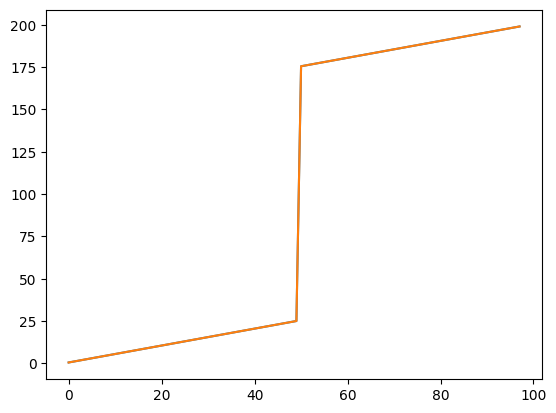

In [25]:
plt.plot(grid.at_node['topographic__elevation'][grid.core_nodes])
plt.plot(grid.at_node['bedrock__elevation'][grid.core_nodes])

In [27]:
for i in range(10):
    fa.run_one_step()
    eroder.run_one_step(1)
    hy.run_one_step(dt=1)
    sg.update_mass_based_on_outsource_dz()
    sg.update_median_grain_size()

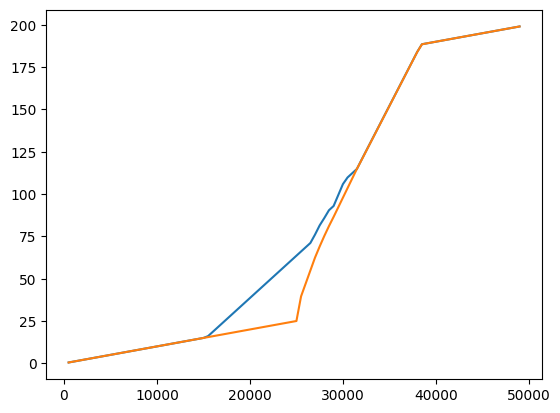

In [28]:
xvec = np.ones_like(grid.at_node['topographic__elevation'][grid.core_nodes])
xvec *= spacing
xvec = np.cumsum(xvec)
plt.plot(xvec,grid.at_node['topographic__elevation'][grid.core_nodes])
plt.plot(xvec,grid.at_node['bedrock__elevation'][grid.core_nodes])
plt.show()

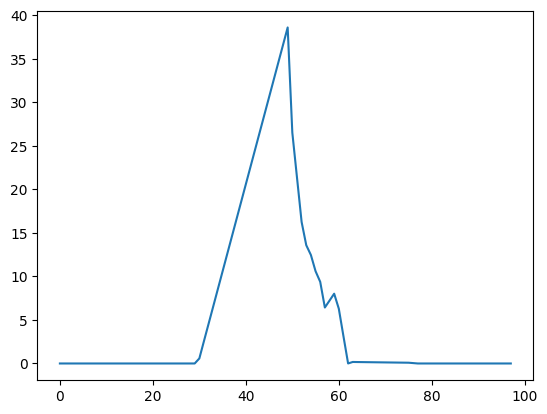

([<matplotlib.lines.Line2D at 0x1754c8f50>], None)

In [29]:
plt.plot(grid.at_node['soil__depth'][grid.core_nodes]),plt.show()

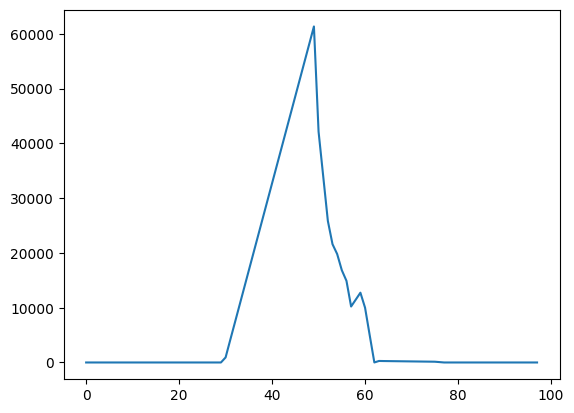

([<matplotlib.lines.Line2D at 0x175432e90>], None)

In [31]:
plt.plot(grid.at_node['grains__weight'][grid.core_nodes,1]),plt.show()

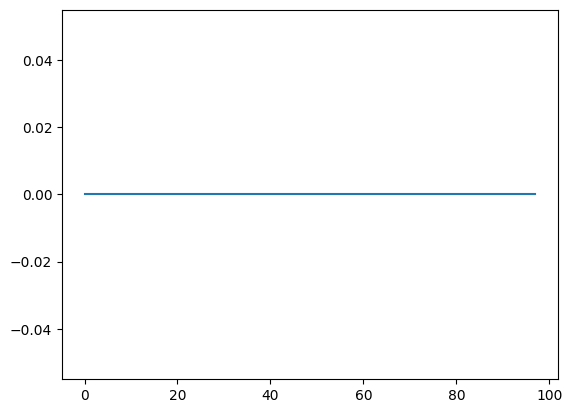

In [32]:
plt.plot(grid.at_node['grains__weight'][grid.core_nodes,0])

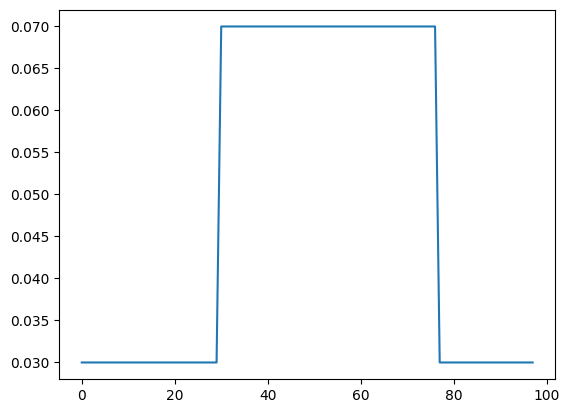

In [33]:
plt.plot(grid.at_node['median_size__weight'][grid.core_nodes])